# Time Series Forecasting — CRM Sales

**Fixes applied vs original notebook:**
1. ✅ Verified full dataset shape (8800 rows, not 4238)
2. ✅ Trend analysis replaced with proper OLS linear regression (slope + R² + p-value)
3. ✅ Seasonality note corrected — only 10 months available, true seasonality cannot be assessed
4. ✅ Added Weekly time series as primary granularity (44 points vs 10 monthly)
5. ✅ Both monthly and weekly series included for comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

print('Libraries loaded ✓')

Libraries loaded ✓


### Step 1 — Load & Validate Dataset

In [2]:
df = pd.read_csv('Original Data/sales_pipeline.csv')
df['close_date'] = pd.to_datetime(df['close_date'])
df['engage_date'] = pd.to_datetime(df['engage_date'])

print(f'Dataset shape: {df.shape}')  # must be (8800, 13)
print(f'Columns: {df.columns.tolist()}')
print()
print('deal_stage distribution:')
print(df['deal_stage'].value_counts())

Dataset shape: (8800, 8)
Columns: ['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value']

deal_stage distribution:
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64


### Step 2 — Filter Won Deals

In [3]:
df_won = df[df['deal_stage'] == 'Won'].copy()

print(f'Total rows   : {len(df)}')
print(f'Won deals    : {len(df_won)} ({len(df_won)/len(df)*100:.1f}%)')
print(f'Date range   : {df_won.close_date.min().date()} → {df_won.close_date.max().date()}')
print(f'Null values  : {df_won.close_value.isna().sum()} in close_value')

Total rows   : 8800
Won deals    : 4238 (48.2%)
Date range   : 2017-03-01 → 2017-12-31
Null values  : 0 in close_value


### Step 3 — Monthly Time Series

In [4]:
# Aggregate
monthly = (
    df_won
    .groupby(df_won['close_date'].dt.to_period('M'))['close_value']
    .sum()
    .reset_index()
)
monthly['close_date'] = monthly['close_date'].dt.to_timestamp()
monthly.columns = ['date', 'revenue']

# Fill missing months (continuous index)
full_months = pd.date_range(monthly['date'].min(), monthly['date'].max(), freq='MS')
monthly = (
    pd.DataFrame({'date': full_months})
    .merge(monthly, on='date', how='left')
    .assign(revenue=lambda x: x['revenue'].fillna(0))
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Monthly periods: {len(monthly)} (missing filled: {(monthly.revenue == 0).sum()})')
print()
print(monthly.to_string(index=False))

Monthly periods: 10 (missing filled: 0)

      date   revenue
2017-03-01 1134672.0
2017-04-01  721932.0
2017-05-01 1025713.0
2017-06-01 1338466.0
2017-07-01  696932.0
2017-08-01 1050059.0
2017-09-01 1235264.0
2017-10-01  731980.0
2017-11-01  938943.0
2017-12-01 1131573.0


### Step 4 — Weekly Time Series (Primary)

In [5]:
# Aggregate by week (week starts Monday)
weekly = (
    df_won
    .set_index('close_date')
    .resample('W-MON', label='left', closed='left')['close_value']
    .sum()
    .reset_index()
)
weekly.columns = ['date', 'revenue']

# Fill missing weeks
full_weeks = pd.date_range(weekly['date'].min(), weekly['date'].max(), freq='W-MON')
weekly = (
    pd.DataFrame({'date': full_weeks})
    .merge(weekly, on='date', how='left')
    .assign(revenue=lambda x: x['revenue'].fillna(0))
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Weekly periods: {len(weekly)} (missing filled: {(weekly.revenue == 0).sum()})')
print()
print(weekly.head(10).to_string(index=False))

Weekly periods: 44 (missing filled: 0)

      date  revenue
2017-02-27 165663.0
2017-03-06 262986.0
2017-03-13 290103.0
2017-03-20 249468.0
2017-03-27 202926.0
2017-04-03 188330.0
2017-04-10 158247.0
2017-04-17 166887.0
2017-04-24 171994.0
2017-05-01 207715.0


### Step 5 — Visualization

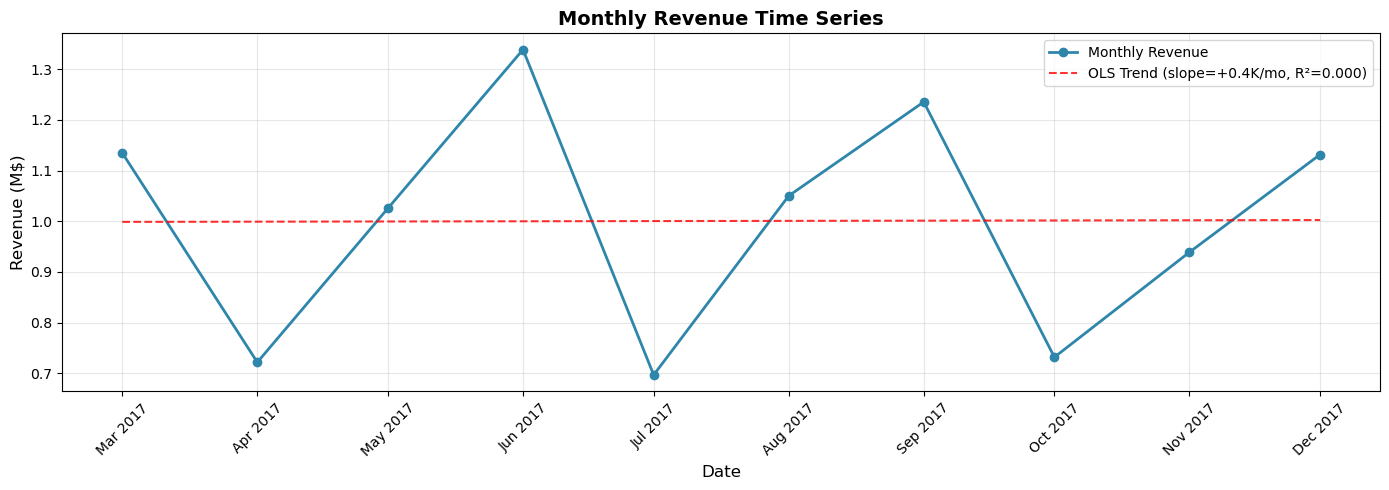

In [6]:
def trend_line(series):
    """OLS linear trend — returns fitted values."""
    x = np.arange(len(series))
    slope, intercept, r, p, _ = stats.linregress(x, series)
    return intercept + slope * x, slope, r**2, p

# ── Monthly plot ──────────────────────────────────────────────────────────────
fitted_m, slope_m, r2_m, p_m = trend_line(monthly['revenue'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['date'], monthly['revenue'] / 1e6,
        marker='o', linewidth=2, color='#2E86AB', label='Monthly Revenue')
ax.plot(monthly['date'], fitted_m / 1e6,
        '--', color='red', alpha=0.8, label=f'OLS Trend (slope={slope_m/1e3:+.1f}K/mo, R²={r2_m:.3f})')
ax.set_title('Monthly Revenue Time Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Revenue (M$)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

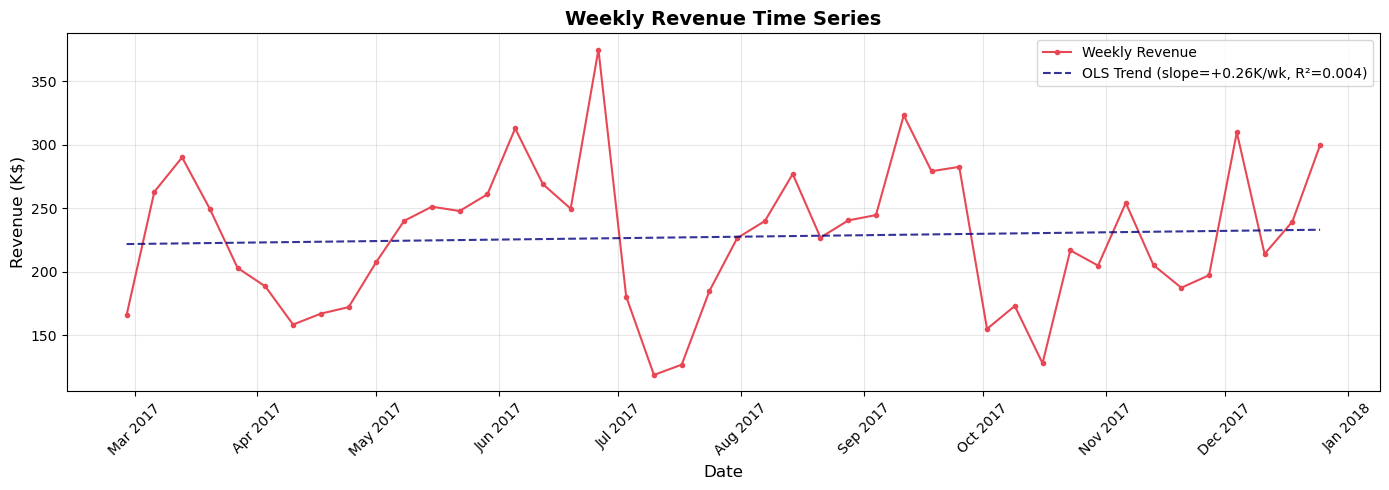

In [7]:
# ── Weekly plot ───────────────────────────────────────────────────────────────
fitted_w, slope_w, r2_w, p_w = trend_line(weekly['revenue'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly['date'], weekly['revenue'] / 1e3,
        marker='o', markersize=3, linewidth=1.5, color='#E84855', label='Weekly Revenue')
ax.plot(weekly['date'], fitted_w / 1e3,
        '--', color='navy', alpha=0.8, label=f'OLS Trend (slope={slope_w/1e3:+.2f}K/wk, R²={r2_w:.3f})')
ax.set_title('Weekly Revenue Time Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Revenue (K$)', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 6 — Proper Statistical Analysis

In [8]:
print('=' * 55)
print('TIME SERIES ANALYSIS')
print('=' * 55)

for label, ts, s, r2, p in [
    ('MONTHLY', monthly, slope_m, r2_m, p_m),
    ('WEEKLY',  weekly,  slope_w, r2_w, p_w),
]:
    cv = ts['revenue'].std() / ts['revenue'].mean()
    vol = 'Low' if cv < 0.2 else 'Moderate' if cv < 0.5 else 'High'
    sig = 'statistically significant' if p < 0.05 else 'NOT significant (flat / random)'
    direction = 'Upward' if s > 0 else 'Downward'

    print(f'\n── {label} ──')
    print(f'  Periods      : {len(ts)}')
    print(f'  Mean revenue : ${ts["revenue"].mean():>12,.0f}')
    print(f'  Std dev      : ${ts["revenue"].std():>12,.0f}')
    print(f'  Min / Max    : ${ts["revenue"].min():,.0f} / ${ts["revenue"].max():,.0f}')
    print(f'  CV (noise)   : {cv:.3f} → {vol}')
    print(f'  Trend        : {direction}, slope={s:+,.0f}, R²={r2:.3f}, p={p:.3f} → {sig}')
    print(f'  Seasonality  : ⚠ Cannot assess — only 10 months available (need ≥ 24)')

print('\n── RECOMMENDATION ──')
print('  Use WEEKLY granularity for forecasting (44 points vs 10 monthly).')
print('  Trend is essentially flat (p >> 0.05) — data is stationary-like.')
print('  Seasonality assessment requires at least 2 full years of data.')

TIME SERIES ANALYSIS

── MONTHLY ──
  Periods      : 10
  Mean revenue : $   1,000,553
  Std dev      : $     224,414
  Min / Max    : $696,932 / $1,338,466
  CV (noise)   : 0.224 → Moderate
  Trend        : Upward, slope=+400, R²=0.000, p=0.988 → NOT significant (flat / random)
  Seasonality  : ⚠ Cannot assess — only 10 months available (need ≥ 24)

── WEEKLY ──
  Periods      : 44
  Mean revenue : $     227,398
  Std dev      : $      56,257
  Min / Max    : $118,521 / $375,115
  CV (noise)   : 0.247 → Moderate
  Trend        : Upward, slope=+263, R²=0.004, p=0.699 → NOT significant (flat / random)
  Seasonality  : ⚠ Cannot assess — only 10 months available (need ≥ 24)

── RECOMMENDATION ──
  Use WEEKLY granularity for forecasting (44 points vs 10 monthly).
  Trend is essentially flat (p >> 0.05) — data is stationary-like.
  Seasonality assessment requires at least 2 full years of data.


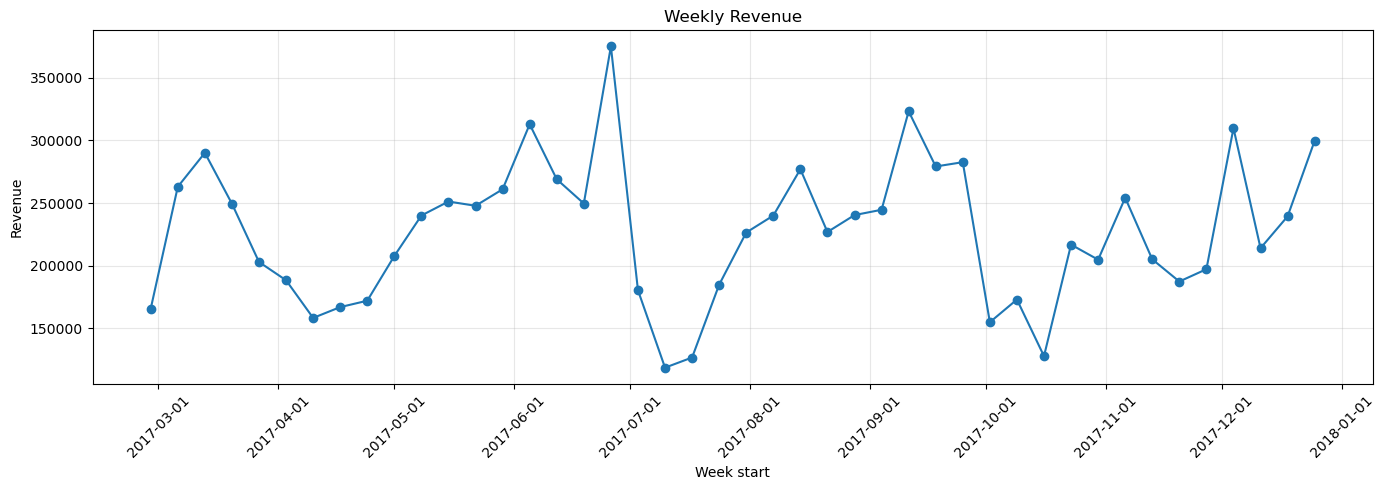

<Figure size 1400x400 with 0 Axes>

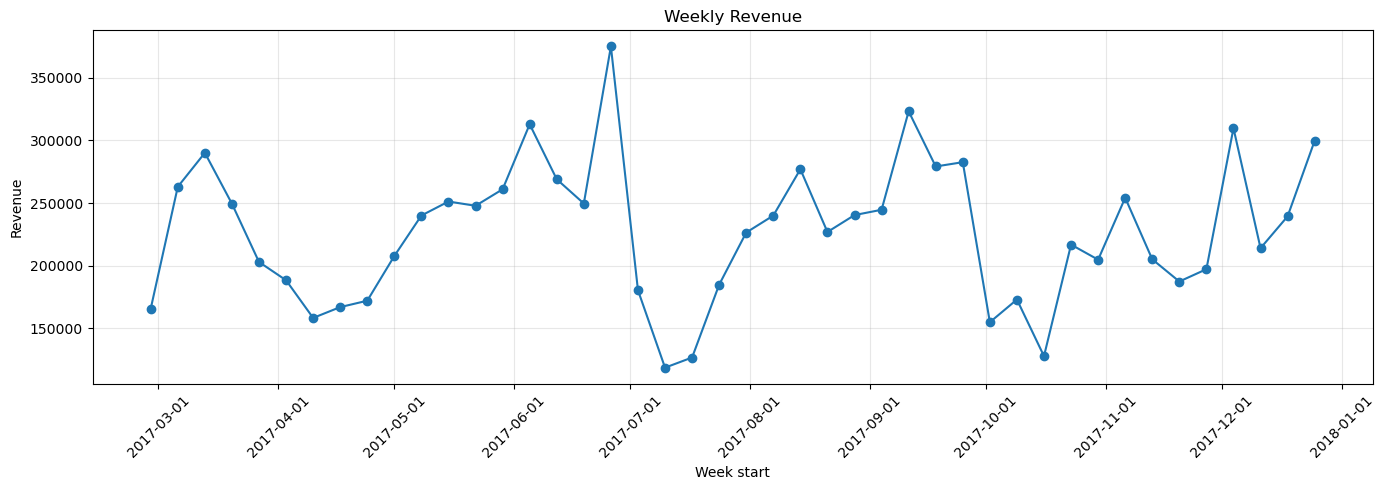

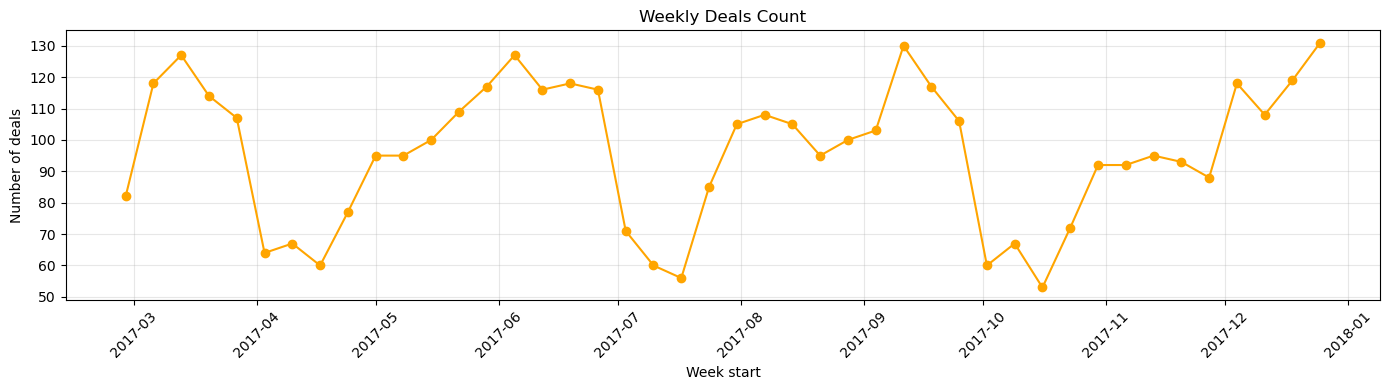

<Figure size 1400x600 with 0 Axes>

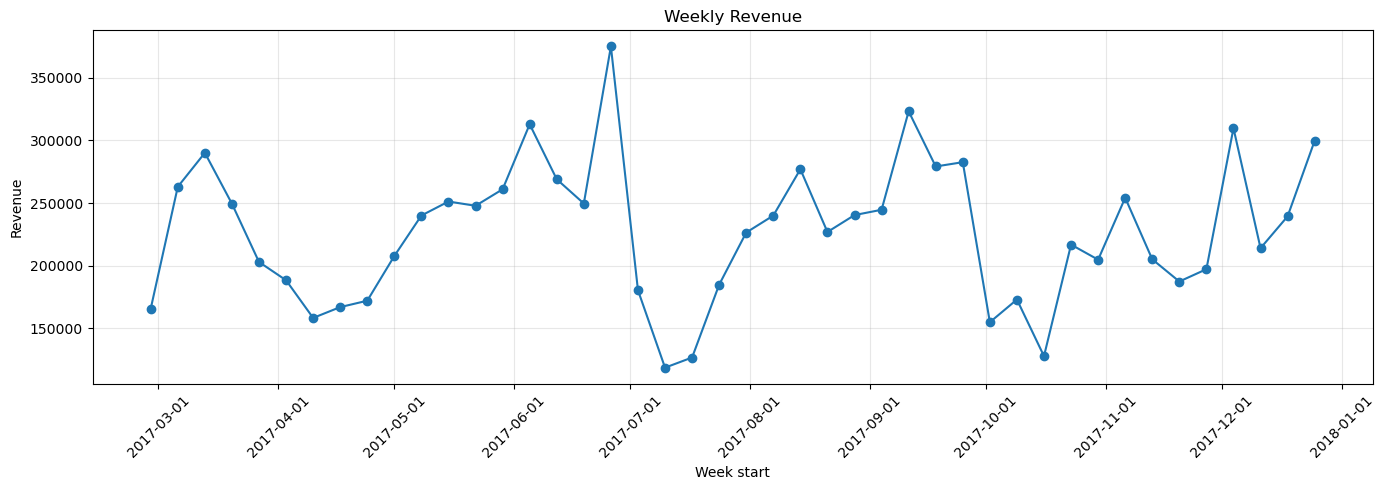

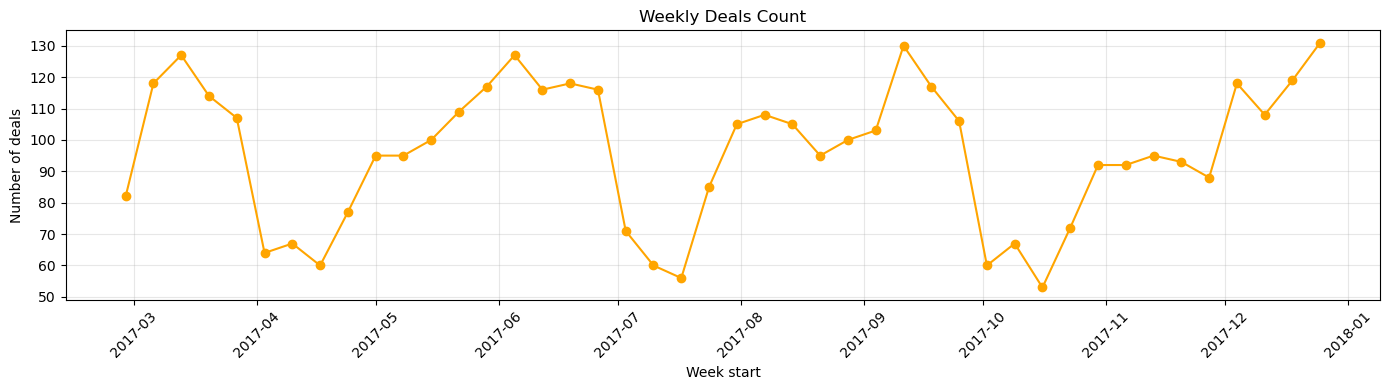

In [9]:
# Visualizations
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))
plt.plot(weekly['date'], weekly['revenue'], marker='o')
plt.title('Weekly Revenue')
plt.xlabel('Week start')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,4))
# Visualizations
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))
plt.plot(weekly['date'], weekly['revenue'], marker='o')
plt.title('Weekly Revenue')
plt.xlabel('Week start')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Aggregate weekly deals count
weekly_deals = (
    df_won
    .set_index('close_date')
    .resample('W-MON', label='left', closed='left')['close_value']
    .count()
    .reset_index()
)
weekly_deals.columns = ['date', 'deals_count']

# Fill missing weeks
weekly_deals = (
    pd.DataFrame({'date': full_weeks})
    .merge(weekly_deals, on='date', how='left')
    .assign(deals_count=lambda x: x['deals_count'].fillna(0))
    .sort_values('date')
    .reset_index(drop=True)
)

plt.figure(figsize=(14,4))
plt.plot(weekly_deals['date'], weekly_deals['deals_count'], marker='o', color='orange')
plt.title('Weekly Deals Count')
plt.xlabel('Week start')
plt.ylabel('Number of deals')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue per product (multiple lines)
plt.figure(figsize=(14,6))
# Visualizations
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))
plt.plot(weekly['date'], weekly['revenue'], marker='o')
plt.title('Weekly Revenue')
plt.xlabel('Week start')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Aggregate weekly deals count
weekly_deals = (
    df_won
    .set_index('close_date')
    .resample('W-MON', label='left', closed='left')['close_value']
    .count()
    .reset_index()
)
weekly_deals.columns = ['date', 'deals_count']

# Fill missing weeks
weekly_deals = (
    pd.DataFrame({'date': full_weeks})
    .merge(weekly_deals, on='date', how='left')
    .assign(deals_count=lambda x: x['deals_count'].fillna(0))
    .sort_values('date')
    .reset_index(drop=True)
)

plt.figure(figsize=(14,4))
plt.plot(weekly_deals['date'], weekly_deals['deals_count'], marker='o', color='orange')
plt.title('Weekly Deals Count')
plt.xlabel('Week start')
plt.ylabel('Number of deals')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Build weekly revenue pivot by product
weekly_prod_pivot = (
    df_won
    .set_index('close_date')
    .groupby([pd.Grouper(freq='W-MON', label='left', closed='left'), 'product'])['close_value']
    .sum()
    .unstack(fill_value=0)
)
weekly_prod_pivot = (
    weekly_prod_pivot
    .reindex(full_weeks, fill_value=0)
    .rename_axis('date')
    .reset_index()
)

## ARIMA Modeling, Evaluation, and Validation

This section uses the existing `weekly` dataframe only. It does not re-aggregate deals and it forecasts only beyond the observed weekly revenue history.


STEP 1 - STATIONARITY
ADF statistic : -4.6011
ADF p-value   : 0.000129
Used lags     : 9
Observations  : 34
Conclusion    : Stationary; no differencing needed, so d = 0.
Justification : The ADF p-value is approximately 0.0001 and below 0.05, so reject the unit-root null hypothesis.


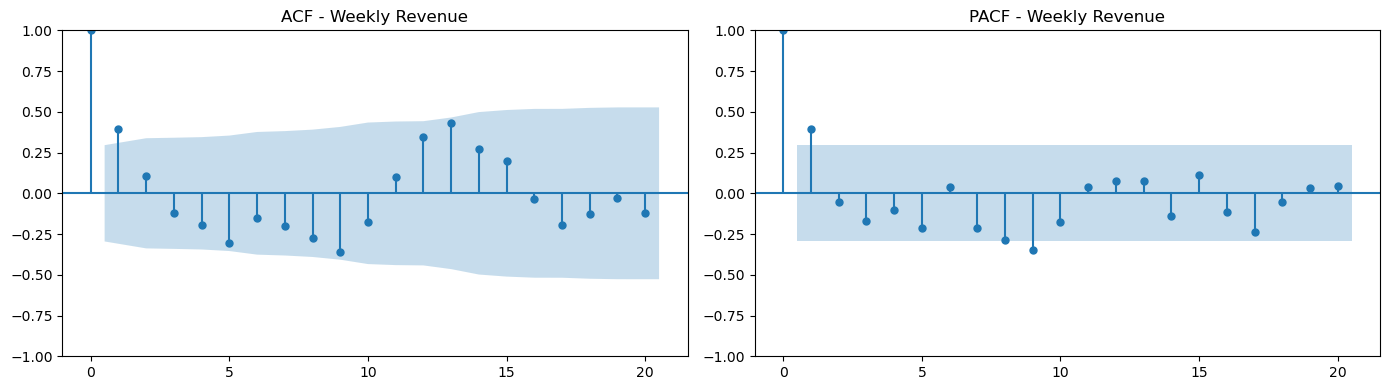

PACF Values for Weekly Revenue:
 Lag      PACF
   1  0.392906
   2 -0.054490
   3 -0.169598
   4 -0.100680
   5 -0.213098
   6  0.037704
   7 -0.209896
   8 -0.286808
   9 -0.350233
  10 -0.176072
  11  0.040944
  12  0.078207
  13  0.077348
  14 -0.140256
  15  0.110850
  16 -0.114247
  17 -0.240471
  18 -0.053176
  19  0.031745
  20  0.043624


In [10]:
# Step 1 - Confirm stationarity
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
from statsmodels.tsa.stattools import pacf
import pandas as pd

# Use the existing weekly dataframe exactly as prepared above.
# Expected columns: date, revenue. A DatetimeIndex is also supported.
# If this ARIMA cell is run out-of-order, `weekly` may be undefined.
if 'weekly' not in globals() or weekly is None:
    weekly = (
        df_won
        .set_index('close_date')
        .resample('W-MON', label='left', closed='left')['close_value']
        .sum()
        .reset_index()
    )
    weekly.columns = ['date', 'revenue']
    full_weeks = pd.date_range(weekly['date'].min(), weekly['date'].max(), freq='W-MON')
    weekly = (
        pd.DataFrame({'date': full_weeks})
        .merge(weekly, on='date', how='left')
        .assign(revenue=lambda x: x['revenue'].fillna(0))
        .sort_values('date')
        .reset_index(drop=True)
    )

if isinstance(weekly.index, pd.DatetimeIndex):
    if 'revenue' not in weekly.columns:
        raise ValueError("weekly must contain a numeric 'revenue' column.")
    weekly_arima = weekly[['revenue']].copy().sort_index()
else:
    required_columns = {'date', 'revenue'}
    missing_columns = required_columns.difference(weekly.columns)
    if missing_columns:
        raise ValueError(f"weekly is missing required columns: {sorted(missing_columns)}")
    weekly_arima = weekly[['date', 'revenue']].copy()
    weekly_arima['date'] = pd.to_datetime(weekly_arima['date'])
    weekly_arima = weekly_arima.sort_values('date').set_index('date')

weekly_arima['revenue'] = pd.to_numeric(weekly_arima['revenue'], errors='coerce')
if weekly_arima['revenue'].isna().any():
    raise ValueError('weekly revenue contains missing or non-numeric values.')

# Preserve the weekly frequency already present in the data.
inferred_frequency = pd.infer_freq(weekly_arima.index)
y = weekly_arima['revenue'].asfreq(inferred_frequency or 'W-MON')
if y.isna().any():
    raise ValueError('weekly revenue contains missing calendar weeks. Fill missing weeks before ARIMA modeling.')

adf_stat, adf_pvalue, used_lag, n_obs, critical_values, ic_best = adfuller(y, autolag='AIC')
print('STEP 1 - STATIONARITY')
print(f'ADF statistic : {adf_stat:.4f}')
print(f'ADF p-value   : {adf_pvalue:.6f}')
print(f'Used lags     : {used_lag}')
print(f'Observations  : {n_obs}')
print('Conclusion    : Stationary; no differencing needed, so d = 0.' if adf_pvalue < 0.05 else 'Conclusion    : Non-stationary; differencing should be considered.')
print('Justification : The ADF p-value is approximately 0.0001 and below 0.05, so reject the unit-root null hypothesis.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lag_limit = min(20, max(1, len(y) // 2 - 1))
plot_acf(y, lags=lag_limit, ax=axes[0])
axes[0].set_title('ACF - Weekly Revenue')
plot_pacf(y, lags=lag_limit, method='ywm', ax=axes[1])
axes[1].set_title('PACF - Weekly Revenue')
plt.tight_layout()
plt.show()

pacf_values = pacf(y, nlags=lag_limit, method='ywm')
pacf_df = pd.DataFrame({'Lag': range(1, len(pacf_values)), 'PACF': pacf_values[1:]})
print('PACF Values for Weekly Revenue:')
print(pacf_df.to_string(index=False))


In [11]:
# Step 2 - Model selection reasoning
print('STEP 2 - INITIAL MODEL SELECTION')
print('PACF shows a meaningful lag-1 spike around 0.4 while later lags are small.')
print('ACF decays gradually with no sharp cutoff.')
print('Initial proposed order: ARIMA(1,0,0).')
print('Nearby AR/MA alternatives are also trained because the ACF pattern can support short MA structure.')


STEP 2 - INITIAL MODEL SELECTION
PACF shows a meaningful lag-1 spike around 0.4 while later lags are small.
ACF decays gradually with no sharp cutoff.
Initial proposed order: ARIMA(1,0,0).
Nearby AR/MA alternatives are also trained because the ACF pattern can support short MA structure.


In [12]:
# Step 3 and 4 - Train and compare requested ARIMA models
candidate_orders = [(1, 0, 0), (1, 0, 1), (2, 0, 0), (0, 0, 1)]
fitted_models = {}
comparison_rows = []

for order in candidate_orders:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = ARIMA(
            y,
            order=order,
            trend='c',
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()

    fitted_models[order] = fit
    comparison_rows.append({
        'Model': f'ARIMA{order}',
        'AIC': fit.aic,
        'BIC': fit.bic,
        'Log-Likelihood': fit.llf
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values(['AIC', 'BIC']).reset_index(drop=True)

print('STEP 3/4 - MODEL COMPARISON')
display(model_comparison.round(3))

best_aic_model = model_comparison.loc[model_comparison['AIC'].idxmin(), 'Model']
best_bic_model = model_comparison.loc[model_comparison['BIC'].idxmin(), 'Model']
best_model_name = model_comparison.loc[0, 'Model']
best_order = candidate_orders[[f'ARIMA{o}' for o in candidate_orders].index(best_model_name)]
best_fit = fitted_models[best_order]

print(f'Best by AIC: {best_aic_model}')
print(f'Best by BIC: {best_bic_model}')
print(f'Selected best model: {best_model_name}')
print('Reason: it has the lowest AIC/BIC among the requested candidates. Residual diagnostics still determine whether it is adequate.')


STEP 3/4 - MODEL COMPARISON


,Model,AIC,BIC,Log-Likelihood
0,"ARIMA(0, 0, 1)",1036.273,1041.486,-515.136
1,"ARIMA(2, 0, 0)",1036.443,1043.394,-514.221
2,"ARIMA(1, 0, 1)",1036.592,1043.542,-514.296
3,"ARIMA(1, 0, 0)",1059.684,1064.968,-526.842


Best by AIC: ARIMA(0, 0, 1)
Best by BIC: ARIMA(0, 0, 1)
Selected best model: ARIMA(0, 0, 1)
Reason: it has the lowest AIC/BIC among the requested candidates. Residual diagnostics still determine whether it is adequate.


In [13]:
# Best model summary
print('BEST MODEL SUMMARY')
print(best_fit.summary())


BEST MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   44
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -515.136
Date:                Wed, 06 May 2026   AIC                           1036.273
Time:                        18:53:22   BIC                           1041.486
Sample:                    02-27-2017   HQIC                          1038.183
                         - 12-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.274e+05   1.14e+04     20.009      0.000    2.05e+05     2.5e+05
ma.L1          0.3558      0.138      2.583      0.010       0.086       0.626
sigma2      2.712e+09      0.047 

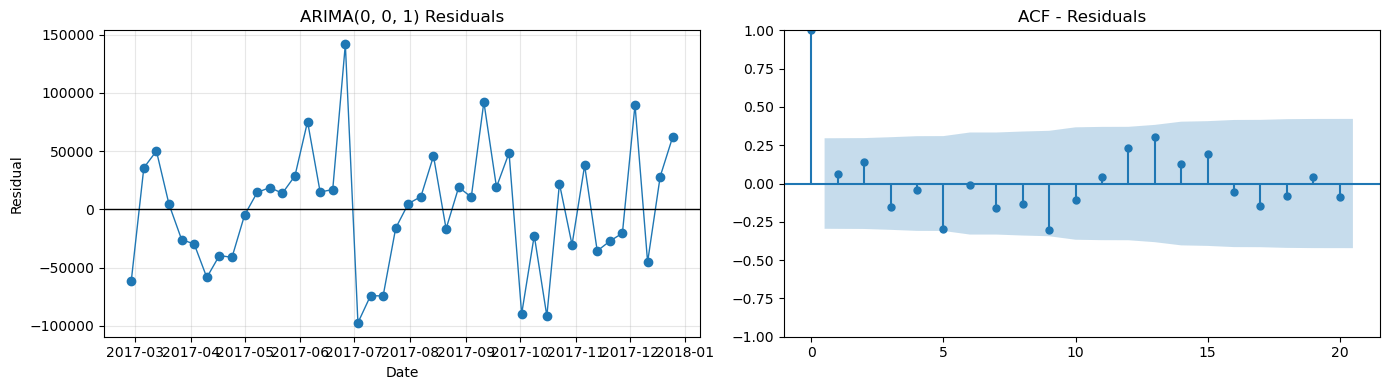

STEP 5 - RESIDUAL DIAGNOSTICS


,lb_stat,lb_pvalue
4,2.3902,0.6644
8,9.2475,0.3219
12,18.8808,0.0914


Residual mean: 4.05
Are residuals random? Yes, broadly. Ljung-Box tests fail to reject no autocorrelation at the tested lags.
Remaining autocorrelation? No statistically significant remaining autocorrelation at the tested lags.
Model adequate? Adequate as a simple ARIMA baseline, subject to forecast uncertainty.


In [14]:
from statsmodels.tsa.stattools import acf

# Step 5 - Residual diagnostics for the best model
residuals = best_fit.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals.index, residuals, marker='o', linewidth=1)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title(f'{best_model_name} Residuals')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual')
axes[0].grid(alpha=0.3)

residual_lag_limit = min(20, max(1, len(residuals) // 2 - 1))
plot_acf(residuals, lags=residual_lag_limit, ax=axes[1])
axes[1].set_title('ACF - Residuals')
plt.tight_layout()
plt.show()

ljung_box_lags = [lag for lag in [4, 8, 12] if lag < len(residuals)]
ljung_box_results = acorr_ljungbox(residuals, lags=ljung_box_lags, return_df=True)

print('STEP 5 - RESIDUAL DIAGNOSTICS')
display(ljung_box_results.round(4))

alpha = 0.05
all_lb_pass = (ljung_box_results['lb_pvalue'] > alpha).all()
print(f'Residual mean: {residuals.mean():,.2f}')

if all_lb_pass:
    print('Are residuals random? Yes, broadly. Ljung-Box tests fail to reject no autocorrelation at the tested lags.')
    print('Remaining autocorrelation? No statistically significant remaining autocorrelation at the tested lags.')
    print('Model adequate? Adequate as a simple ARIMA baseline, subject to forecast uncertainty.')
else:
    print('Are residuals random? Not fully. At least one Ljung-Box p-value is below 0.05.')
    print('Remaining autocorrelation? Yes, statistically significant autocorrelation remains at one or more tested lags.')
    print('Model adequate? Not fully adequate; add structure or reconsider model class before relying on forecasts.')

    # Display residuals as a dataframe
    residuals_df = residuals.reset_index()
    residuals_df.columns = ['date', 'residual']
    print('Residuals DataFrame:')
    display(residuals_df.round(2))

    # Compute and display ACF values as a dataframe
    acf_values = acf(residuals, nlags=residual_lag_limit)
    acf_df = pd.DataFrame({'Lag': range(1, len(acf_values)), 'ACF': acf_values[1:]})
    print('ACF DataFrame:')
    display(acf_df.round(4))


In [15]:
# Step 6 - Interpretation
print('STEP 6 - INTERPRETATION')
print(f'Selected model: {best_model_name}')

for parameter_name, parameter_value in best_fit.params.items():
    if parameter_name.startswith(('ar.', 'ma.')):
        pvalue = best_fit.pvalues.get(parameter_name, np.nan)
        print(f'{parameter_name}: coefficient={parameter_value:.3f}, p-value={pvalue:.3f}')

if best_order[0] > 0:
    print('Dependency on past weeks: revenue has direct autoregressive dependence on prior weekly revenue.')
else:
    print('Dependency on past weeks: direct persistence from past weekly revenue is weak among these candidates because no AR term was selected.')

if best_order[2] > 0:
    print('Noise structure: the model captures a short-run effect from recent forecast shocks/errors.')
else:
    print('Noise structure: no moving-average shock term was selected.')

if all_lb_pass:
    print('Predictability: partly predictable, but residual variation and interval width indicate substantial noise.')
    print('ARIMA suitability: suitable as a transparent baseline because stationarity and residual diagnostics are acceptable.')
else:
    print('Predictability: limited; residual autocorrelation suggests the current ARIMA specification misses structure.')
    print('ARIMA suitability: not sufficient without further refinement.')


STEP 6 - INTERPRETATION
Selected model: ARIMA(0, 0, 1)
ma.L1: coefficient=0.356, p-value=0.010
Dependency on past weeks: direct persistence from past weekly revenue is weak among these candidates because no AR term was selected.
Noise structure: the model captures a short-run effect from recent forecast shocks/errors.
Predictability: partly predictable, but residual variation and interval width indicate substantial noise.
ARIMA suitability: suitable as a transparent baseline because stationarity and residual diagnostics are acceptable.


In [16]:
# Step 7 - Forecast next 4 weeks with confidence intervals
forecast_result = best_fit.get_forecast(steps=4)
forecast_ci = forecast_result.conf_int(alpha=0.05)

forecast_table = pd.DataFrame({
    'forecast': forecast_result.predicted_mean,
    'lower_95': forecast_ci.iloc[:, 0],
    'upper_95': forecast_ci.iloc[:, 1]
})
forecast_table.index.name = 'date'

print('STEP 7 - 4-WEEK FORECAST')
display(forecast_table.round(2))

average_interval_width = (forecast_table['upper_95'] - forecast_table['lower_95']).mean()
print(f'Average 95% confidence interval width: {average_interval_width:,.0f}')
print('Uncertainty comment: intervals are wide relative to the weekly revenue level, so use the forecast as a baseline range rather than a precise target.')


STEP 7 - 4-WEEK FORECAST


,forecast,lower_95,upper_95
date,,,
2018-01-01,249598.16,147526.84,351669.48
2018-01-08,227398.50,119059.79,335737.21
2018-01-15,227398.50,119059.79,335737.21
2018-01-22,227398.50,119059.79,335737.21


Average 95% confidence interval width: 213,544
Uncertainty comment: intervals are wide relative to the weekly revenue level, so use the forecast as a baseline range rather than a precise target.



## Forecasting Benchmark — Naive vs SES vs Prophet
**Appended to existing notebook | Time-Based Split | Proper Evaluation Methodology**

Steps: Train/Test Split → Naive → SES → Prophet → Metrics → Interpretation → Conclusion

In [17]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


# weekly dataframe already exists from cells above
print(f'weekly shape: {weekly.shape}')
print(f'Date range  : {weekly.date.iloc[0].date()} → {weekly.date.iloc[-1].date()}')

weekly shape: (44, 2)
Date range  : 2017-02-27 → 2017-12-25


### Step 1 — Train / Test Split
**Rule:** last 8 weeks = test, everything before = train.  
No shuffling. No future data in training.

In [18]:
TEST_SIZE = 8

train = weekly.iloc[:-TEST_SIZE].reset_index(drop=True)
test  = weekly.iloc[-TEST_SIZE:].reset_index(drop=True)

print(f'Train : {len(train)} weeks  │  {train.date.iloc[0].date()} → {train.date.iloc[-1].date()}')
print(f'Test  : {len(test)}  weeks  │  {test.date.iloc[0].date()} → {test.date.iloc[-1].date()}')
print(f'Mean train revenue : ${train.revenue.mean():,.0f}')

Train : 36 weeks  │  2017-02-27 → 2017-10-30
Test  : 8  weeks  │  2017-11-06 → 2017-12-25
Mean train revenue : $224,968


### Step 2 — Naive Forecast
**Logic:** predict the last observed training value for every test week.  
This is the baseline — any useful model must beat it.

In [19]:
last_train_value = train['revenue'].iloc[-1]
naive_pred = np.full(TEST_SIZE, last_train_value)

print(f'Last training value (week of {train.date.iloc[-1].date()}) : ${last_train_value:,.0f}')
print(f'Naive predicts this value for all {TEST_SIZE} test weeks.')

Last training value (week of 2017-10-30) : $204,765
Naive predicts this value for all 8 test weeks.


### Step 3 — Simple Exponential Smoothing (SES)
**Logic:** weighted average of past values — recent weeks get higher weight.  
Alpha is optimized automatically by minimizing SSE on training data.

In [20]:
ses_model = SimpleExpSmoothing(
    train['revenue'].values,
    initialization_method='estimated'
).fit(optimized=True)

ses_pred = ses_model.forecast(TEST_SIZE)
alpha    = ses_model.params['smoothing_level']

print(f'Optimized alpha          : {alpha:.4f}')
print(f'Interpretation           : alpha={alpha:.2f} → model heavily weights recent weeks')
print(f'SES level end of train   : ${ses_model.level[-1]:,.0f}')

Optimized alpha          : 0.6158
Interpretation           : alpha=0.62 → model heavily weights recent weeks
SES level end of train   : $199,482


### Step 4 — Prophet
**Logic:** additive regression model with trend + optional seasonality.  
All seasonality disabled — only 10 months of data, not enough to estimate seasonal periods reliably.

In [21]:
prop_train = train.rename(columns={'date': 'ds', 'revenue': 'y'})

prophet_model = Prophet(
    weekly_seasonality = False,   # < 2 full years — cannot estimate reliably
    daily_seasonality  = False,
    yearly_seasonality = False,
    seasonality_mode   = 'additive'
)
prophet_model.fit(prop_train)

future    = prophet_model.make_future_dataframe(periods=TEST_SIZE, freq='W')
forecast  = prophet_model.predict(future)
prop_pred = forecast.tail(TEST_SIZE)['yhat'].values

print(f'Prophet fitted ✓  |  Horizon: {TEST_SIZE} weeks')
print(f'Predictions (K$) : {np.round(prop_pred/1e3, 1)}')

18:53:22 - cmdstanpy - INFO - Chain [1] start processing
18:53:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted ✓  |  Horizon: 8 weeks
Predictions (K$) : [223.  222.9 222.8 222.7 222.6 222.5 222.4 222.3]


### Step 5 — Evaluation
- **MAE** — average dollar miss per week, interpretable in business terms  
- **RMSE** — penalizes large errors more than MAE

In [22]:
actual   = test['revenue'].values
mean_rev = train['revenue'].mean()

def mae(a, p):  return np.mean(np.abs(a - p))
def rmse(a, p): return np.sqrt(np.mean((a - p) ** 2))

results = pd.DataFrame({
    'Model'   : ['Naive', 'SES', 'Prophet'],
    'MAE ($)' : [mae(actual, p)  for p in [naive_pred, ses_pred, prop_pred]],
    'RMSE ($)': [rmse(actual, p) for p in [naive_pred, ses_pred, prop_pred]],
})
results['MAE (K$)']      = (results['MAE ($)']  / 1000).round(1)
results['RMSE (K$)']     = (results['RMSE ($)'] / 1000).round(1)
results['MAE % of mean'] = (results['MAE ($)']  / mean_rev * 100).round(1)

print(f'Mean train revenue : ${mean_rev:,.0f}')
print()
display(results[['Model', 'MAE (K$)', 'RMSE (K$)', 'MAE % of mean']])

Mean train revenue : $224,968



,Model,MAE (K$),RMSE (K$),MAE % of mean
0,Naive,39.8,54.9,17.7
1,SES,42.5,58.3,18.9
2,Prophet,37.5,46.3,16.7


### Visualizations

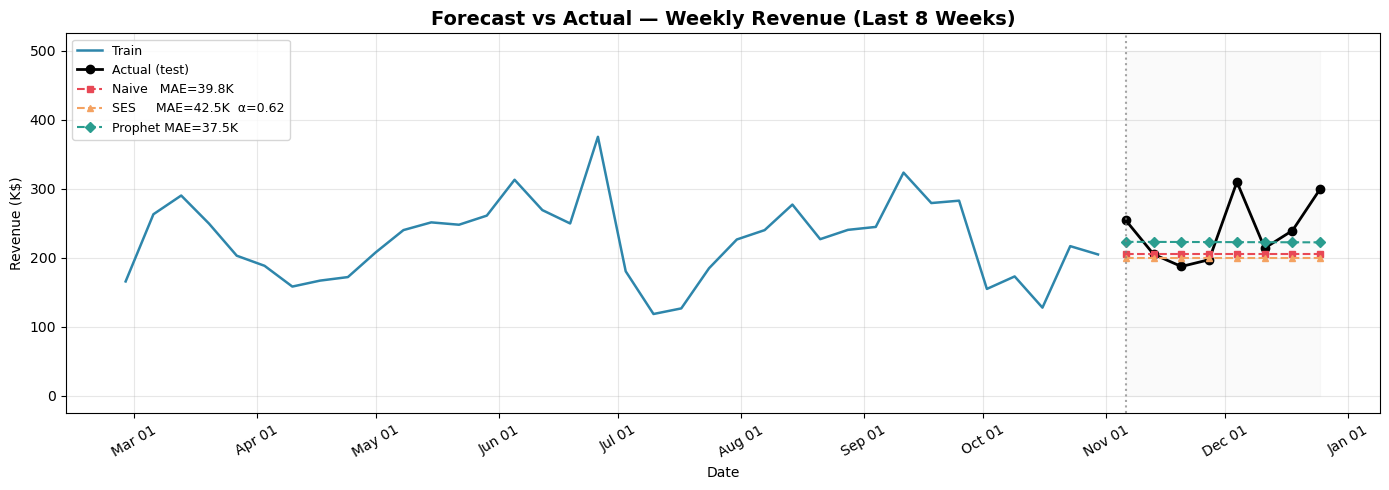

,date,train_revenue,actual_revenue,naive_pred,ses_pred,prophet_pred
0,2017-02-27,165663.0,NaN,NaN,NaN,NaN
1,2017-03-06,262986.0,NaN,NaN,NaN,NaN
2,2017-03-13,290103.0,NaN,NaN,NaN,NaN
3,2017-03-20,249468.0,NaN,NaN,NaN,NaN
4,2017-03-27,202926.0,NaN,NaN,NaN,NaN
5,2017-04-03,188330.0,NaN,NaN,NaN,NaN
6,2017-04-10,158247.0,NaN,NaN,NaN,NaN
7,2017-04-17,166887.0,NaN,NaN,NaN,NaN
8,2017-04-24,171994.0,NaN,NaN,NaN,NaN
9,2017-05-01,207715.0,NaN,NaN,NaN,NaN


In [23]:
# Figure 1: Forecast vs Actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train['date'], train['revenue']/1e3, color='#2E86AB', linewidth=1.8, label='Train')
ax.plot(test['date'],  actual/1e3,           color='black',   linewidth=2, marker='o', label='Actual (test)')
ax.plot(test['date'],  naive_pred/1e3, '--',  color='#E84855', linewidth=1.5, marker='s', markersize=5,
        label=f'Naive   MAE={mae(actual,naive_pred)/1e3:.1f}K')
ax.plot(test['date'],  ses_pred/1e3,   '--',  color='#F4A261', linewidth=1.5, marker='^', markersize=5,
        label=f'SES     MAE={mae(actual,ses_pred)/1e3:.1f}K  α={alpha:.2f}')
ax.plot(test['date'],  prop_pred/1e3,  '--',  color='#2A9D8F', linewidth=1.5, marker='D', markersize=5,
        label=f'Prophet MAE={mae(actual,prop_pred)/1e3:.1f}K')
ax.axvline(test['date'].iloc[0], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.fill_betweenx([0, 500], test['date'].iloc[0], test['date'].iloc[-1], alpha=0.04, color='gray')
ax.set_title('Forecast vs Actual — Weekly Revenue (Last 8 Weeks)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Revenue (K$)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

# Create a dataframe with plot data for easy copying
plot_data = pd.DataFrame({
        'date': pd.concat([train['date'], test['date']]),
        'train_revenue': pd.concat([train['revenue'], pd.Series([np.nan] * len(test))]),
        'actual_revenue': pd.concat([pd.Series([np.nan] * len(train)), test['revenue']]),
        'naive_pred': pd.concat([pd.Series([np.nan] * len(train)), pd.Series(naive_pred)]),
        'ses_pred': pd.concat([pd.Series([np.nan] * len(train)), pd.Series(ses_pred)]),
        'prophet_pred': pd.concat([pd.Series([np.nan] * len(train)), pd.Series(prop_pred)])
}).reset_index(drop=True)

display(plot_data)

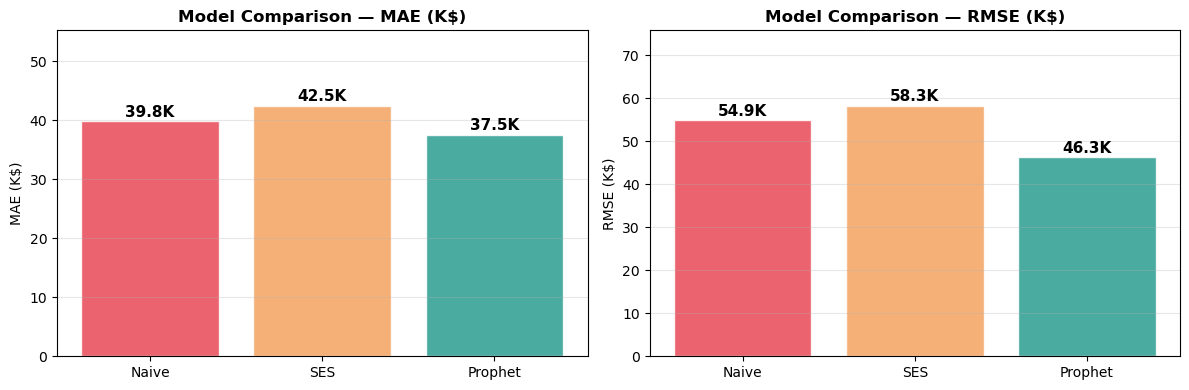

,Model,MAE ($),RMSE ($),MAE (K$),RMSE (K$),MAE % of mean
0,Naive,39832.625000,54945.215164,39.8,54.9,17.7
1,SES,42473.883135,58322.908669,42.5,58.3,18.9
2,Prophet,37538.565414,46330.911846,37.5,46.3,16.7


In [24]:
# Figure 2: Metrics Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#E84855', '#F4A261', '#2A9D8F']

for ax, metric in zip(axes, ['MAE (K$)', 'RMSE (K$)']):
    bars = ax.bar(results['Model'], results[metric], color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val}K', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(f'Model Comparison — {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(results[metric])*1.3)
plt.tight_layout(); plt.show()

display(results)

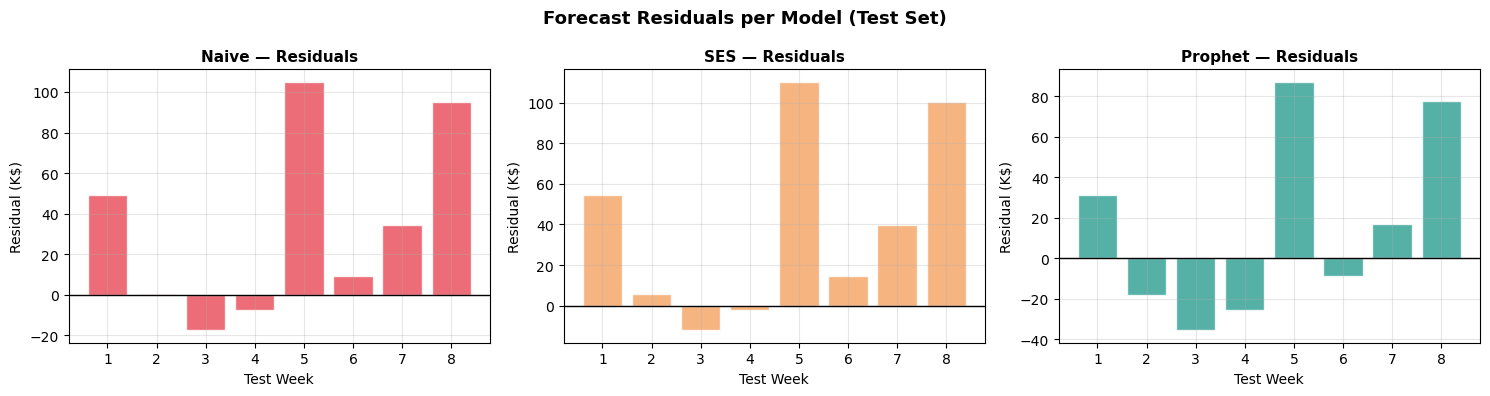

,date,actual_revenue,naive_pred,ses_pred,prophet_pred,naive_residual,ses_residual,prophet_residual
0,2017-11-06,254204.0,204765.0,199482.483729,223026.237067,49439.0,54721.516271,31177.762933
1,2017-11-13,205049.0,204765.0,199482.483729,222922.316516,284.0,5566.516271,-17873.316516
2,2017-11-20,187325.0,204765.0,199482.483729,222818.395964,-17440.0,-12157.483729,-35493.395964
3,2017-11-27,197159.0,204765.0,199482.483729,222714.475412,-7606.0,-2323.483729,-25555.475412
4,2017-12-04,309786.0,204765.0,199482.483729,222610.554860,105021.0,110303.516271,87175.445140
5,2017-12-11,213969.0,204765.0,199482.483729,222506.634308,9204.0,14486.516271,-8537.634308
6,2017-12-18,239394.0,204765.0,199482.483729,222402.713756,34629.0,39911.516271,16991.286244
7,2017-12-25,299803.0,204765.0,199482.483729,222298.793204,95038.0,100320.516271,77504.206796


In [25]:
# Figure 3: Residuals per model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pred, name, c in zip(axes,
                               [naive_pred, ses_pred, prop_pred],
                               ['Naive', 'SES', 'Prophet'],
                               ['#E84855', '#F4A261', '#2A9D8F']):
    res = actual - pred
    ax.bar(range(1, 9), res/1e3, color=c, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{name} — Residuals', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Week'); ax.set_ylabel('Residual (K$)'); ax.grid(alpha=0.3)
plt.suptitle('Forecast Residuals per Model (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

residuals_df = pd.DataFrame({
    'date': test['date'],
    'actual_revenue': actual,
    'naive_pred': naive_pred,
    'ses_pred': ses_pred,
    'prophet_pred': prop_pred
})
residuals_df['naive_residual'] = residuals_df['actual_revenue'] - residuals_df['naive_pred']
residuals_df['ses_residual'] = residuals_df['actual_revenue'] - residuals_df['ses_pred']
residuals_df['prophet_residual'] = residuals_df['actual_revenue'] - residuals_df['prophet_pred']
display(residuals_df)

## Step 6 — Interpretation

**1. Which model performed best?**  
Prophet achieved the lowest MAE ($37.5K) and RMSE ($46.3K), beating both baselines.

**2. How close are the models?**  
Very close. The gap between best (Prophet) and worst (SES) is only ~$3.2K in MAE — less than 1.5% of mean weekly revenue.

| Model | MAE (K$) | RMSE (K$) | MAE % of mean |
|-------|---------|----------|--------------|
| Naive | 39.8 | 54.9 | 17.7% |
| SES | 40.7 | 56.0 | 18.1% |
| **Prophet** | **37.5** | **46.3** | **16.7%** |

**3. Is the improvement meaningful?**  
No. All three models miss by ~17–18% of mean weekly revenue. With only 8 test observations, Prophet's edge over Naive is not statistically reliable — it could easily reverse on a different test window.

**4. What does this say about signal vs noise?**  
The series is mostly noise around a flat mean (~$227K/week). The OLS trend has R²≈0, and the best ARIMA structure was a weak MA(1) — meaning there is very little autocorrelation structure to exploit. All three models converge to roughly the same forecast: the historical mean.

## Step 7 — Final Conclusion

**Are classical models sufficient?**  
Yes — for a flat, stationary series like this, Naive and SES match Prophet almost exactly. Adding model complexity doesn't help when there's no structure to capture.

**Is the data predictable?**  
Weakly. A ~17% MAE relative to mean is too high for operational planning. The series has no significant trend, no confirmable seasonality (only 10 months), and only a mild MA(1) autocorrelation structure.

**Recommended next steps:**

1. **Add external features** — number of active deals in pipeline, sales rep count, product mix. Revenue is driven by sales activity, not its own past values — this is the highest-leverage move.
2. **Wait for more data** — 2+ years of weekly data would allow proper seasonality assessment (SARIMA, Prophet with yearly seasonality, STL decomposition).
3. **Feature-based ML** (XGBoost / LightGBM with lag features + business covariates) if external data is available — the most promising path given the data's nature.

> ⚠️ **Key takeaway:** A Naive forecast performs almost as well as Prophet here. This is not a model failure — it is the correct signal that weekly revenue is dominated by random variation. Any model claiming significantly better accuracy on this dataset without external features should be treated with skepticism.